In [2]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

addArchRThreads(12)
options(repr.plot.width=15, repr.plot.height=10)

ERROR: Error: Could not find associated project in working directory or any parent directory.
- Path in project: 01_create_arrow.R
- Current working directory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR
Please open the project associated with this file and try again.


In [3]:
matrix = 'GeneIntegrationMatrix_PeakMatrix'#'GeneScoreMatrix'
maxDist = 80000
TF_peak_corr_thr = 0.4

In [4]:
# Motif enrichment
#ArchRProject <- addMotifAnnotations(ArchRProj = ArchRProject, motifSet = "cisbp", name = "Motif", species='Homo sapiens', force=TRUE)

In [5]:
# get peak-motif matrix
matches = getMatches(ArchRProject)

colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(sapply(strsplit(genes, ':'), '[', 2), TFs)


In [6]:

# get peaks
peaks = getPeakSet(ArchRProject)
peaks$idx = 1:length(peaks) # create unique peak IDs

# get expressions
genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names



Warning message in mclapply(..., mc.cores = threads, mc.preschedule = preschedule):
“1 function calls resulted in an error”


ERROR: Error in .safelapply(seq_along(ArrowFiles), function(x) {: 
Error Found Iteration 1 : 
	[1] "Error : Error in h5checktype(). H5Identifier not valid.\n"
	<simpleError: Error in h5checktype(). H5Identifier not valid.>



In [9]:
# get peak accessibility
addArchRThreads(1)

peakacc = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")
peakacc = assays(peakacc)$PeakMatrix
rownames(peakacc) = 1:nrow(peakacc)

Setting default number of Parallel threads to 1.



In [10]:
peakacc[1:10,1:10]

   [[ suppressing 10 column names ‘rabbit_BGRGP1#AATGTCGAGTTCAGGG-1’, ‘rabbit_BGRGP1#TAGCACACACTCGCAG-1’, ‘rabbit_BGRGP1#GAAGAGCGTATCTCAG-1’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                      
1  . . . . . . . 2 . .
2  2 . . . 2 . 2 2 . 2
3  2 . 2 . . . 4 1 . .
4  . . 1 2 . . 4 . . .
5  . . . . 2 . . 2 . .
6  . . . . . . . . . .
7  . . . . . . . 2 . .
8  4 1 . . 2 2 2 . 2 2
9  . 2 . . . . 2 . . .
10 . . . . 4 . . 1 . .

In [11]:
addArchRThreads(12)

# # Add peak to gene links
# ArchRProject = addPeak2GeneLinks(
#     ArchRProj = ArchRProject,
#     reducedDims = "PeakMatrix",
#     useMatrix = matrix,
#     dimsToUse = 1:30,
#     maxDist = maxDist) # The max distance should probably be greatly reduced

# Retrieve peak to gene links
peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
                                corCutOff = 0.45,
                                FDRCutOff = 1e-04, # test with more stringent values
                                varCutOffATAC = 0.25,
                                varCutOffRNA = 0.25,)

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                      idxRNA = peak_gene_links$idxRNA,
                      idxATAC = peak_gene_links$idxATAC)


linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])



Setting default number of Parallel threads to 12.



In [12]:
TF = 'TAL2'

In [13]:
    print(TF)
    # get peaks that have TF motif
    TF_peak_ids = matches[matches@assays@data$matches[, TF]]@rowRanges$idx

    TF_peaks = linked_peaks[idx %in% TF_peak_ids,]

    # filter peaks that are correlate to expression of TF

    # get imputed TF expression
    TF_expr = genescores[TF,]
    TF_expr_imp = suppressMessages(imputeMatrix(mat = as.matrix(t(TF_expr)), 
                                 imputeWeights = getImputeWeights(ArchRProject)))
    # get imputed peak accessibility
    peak_subset = peakacc[TF_peaks$idx,]
    peak_subset_imp = suppressMessages(imputeMatrix(mat = as.matrix(peak_subset), 
                                 imputeWeights = getImputeWeights(ArchRProject)))

[1] "TAL2"


In [17]:
a = Sys.time()
TF_peak_cor = apply(peak_subset_imp, 1, function(x){cor(x, TF_expr_imp)})
b = Sys.time()
b-a

Time difference of 1.559273 secs

In [19]:
library(parallel)

In [ ]:
GetTFtargets = function(TF = 'TAL1', TF_peak_corr_thr=0.4){
    stopifnot(TF %in% TFs)
    print(TF)
    # get peaks that have TF motif
    TF_peak_ids = matches[matches@assays@data$matches[, TF]]@rowRanges$idx

    TF_peaks = linked_peaks[idx %in% TF_peak_ids,]

    # filter peaks that are correlate to expression of TF

    # get imputed TF expression
    TF_expr = genescores[TF,]
    TF_expr_imp = suppressMessages(imputeMatrix(mat = as.matrix(t(TF_expr)), 
                                 imputeWeights = getImputeWeights(ArchRProject)))
    # get imputed peak accessibility
    peak_subset = peakacc[TF_peaks$idx,]
    peak_subset_imp = suppressMessages(imputeMatrix(mat = as.matrix(peak_subset), 
                                 imputeWeights = getImputeWeights(ArchRProject)))

    # Get correlated peaks, very naive method
    TF_peak_cor = apply(peak_subset_imp, 1, function(x){cor(x, TF_expr_imp)})
    corr_peaks = names(TF_peak_cor[TF_peak_cor>TF_peak_corr_thr])

    # keep genes that are linked to peaks that are correlated with TF and have its motif
    TF_genes = linked_genes[idxATAC %in% corr_peaks] %>% .[order(match(idxATAC,TF_peaks$idx)),]

    # Count how many peaks regulate the genes
    TF_genes = TF_genes %>% .[, N:=.N, by=gene] %>% unique(by='gene') %>% .[order(-N),]
    # TF_genes = TF_genes[!grep('ENS', TF_genes$gene)]

    return(TF_genes)
}

In [ ]:
TF_targets = lapply(TFs[1:10], function(x){
    GetTFtargets(x, TF_peak_corr_thr=0.2) %>% 
    .[gene %in% TFs]} %>%
    .[,TF:=x])

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

...

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standard deviation is zero”
Warning message in cor(x, TF_expr_imp):
“the standa

In [ ]:
rbindlist(TF_targets)

In [346]:
targets

gene,idxRNA,idxATAC,N
<chr>,<int>,<int>,<int>
ENSOCUG00000031710,243,2286,1
ENSOCUG00000018236,439,3881,1
RNF214,907,8421,1
ENSOCUG00000023399,1156,10227,1
ENSOCUG00000000567,1419,12334,1


In [72]:
# Add peak to gene links
ArchRProject = addPeak2GeneLinks(
  ArchRProj = ArchRProject,
  reducedDims = "PeakMatrix",
  useMatrix = matrix,
  dimsToUse = 1:30,
  maxDist = maxDist) # The max distance should probably be greatly reduced

In [188]:
# Retrieve peak to gene links
peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
                                    corCutOff = 0.45,
                                    FDRCutOff = 1e-04, # test with more stringent values
                                    varCutOffATAC = 0.25,
                                    varCutOffRNA = 0.25,)

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                          idxRNA = peak_gene_links$idxRNA,
                          idxATAC = peak_gene_links$idxATAC)
                         

linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])

In [43]:
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(genes, TFs)

In [44]:
colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)

### test specific TF

In [259]:
TF = 'DLX5'

In [262]:
# get peaks that have TF motif
TF_peak_ids = matches[matches@assays@data$matches[, TF]]@rowRanges$idx

TF_peaks = linked_peaks[idx %in% TF_peak_ids,]

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'i' in selecting a method for function '[': invalid character indexing


In [145]:
# filter out peaks that are correlate to expression of TF
addArchRThreads(1)

# get imputed TF expression
TF_expr = genescores[TF,]
TF_expr_imp = suppressMessages(imputeMatrix(mat = as.matrix(t(TF_expr)), 
                                     imputeWeights = getImputeWeights(ArchRProject)))
# get imputed peak accessibility
peak_subset = peakacc[TF_peaks$idx,]
peak_subset_imp = suppressMessages(imputeMatrix(mat = as.matrix(peak_subset), 
                                     imputeWeights = getImputeWeights(ArchRProject)))

In [193]:
# get imputed peak accessibility
peak_subset = peakacc[TF_peaks$idx,]
peak_subset_imp = suppressMessages(imputeMatrix(mat = as.matrix(peak_subset), 
                                     imputeWeights = getImputeWeights(ArchRProject)))

In [207]:
# Get correlated peaks, very naive method
TF_peak_cor = apply(peak_subset_imp, 1, function(x){cor(x, TF_expr_imp)})
corr_peaks = names(TF_peak_cor[TF_peak_cor>TF_peak_corr_thr])

In [211]:
TF_genes = linked_genes[idxATAC %in% corr_peaks] %>% .[order(match(idxATAC,TF_peaks$idx)),]

In [213]:
TF_genes = TF_genes %>% .[, N:=.N, by=gene] %>% unique(by='gene') %>% .[order(-N),]
TF_genes = TF_genes[!grep('ENS', TF_genes$gene)]

In [215]:
head(TF_genes)

gene,idxRNA,idxATAC,N
<chr>,<int>,<int>,<int>
GOLM1,615,5975,5
ENHO,229,2109,4
TLN1,189,1924,1
SNX19,704,7005,1


In [383]:
write.csv(TF_genes$gene, file.path(io$basedir, 'GO_test.csv'), row.names=FALSE, quote=FALSE)

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]     chr1 72131198-72165745      - | ENSOCUG00000001999       GOLM1
  -------
  seqinfo: 22 sequences from an unspecified genome


2022-03-22 11:09:26 : SuppressedMessaged due to getArchRVerbose() is FALSE!

Length of unique values greater than palette, interpolating..

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Length of unique values greater than palette, interpolating..

Warning message:
“Removed 61 rows containing missing values (position_stack).”
Picking joint bandwidth of 0.0911

Picking joint bandwidth of 0.0948

Picking joint bandwidth of 0.0979

Picking joint bandwidth of 0.0878

Picking joint bandwidth of 0.111

Picking joint bandwidth of 0.0819

Picking joint bandwidth of 0.117

Picking joint bandwidth of 0.104

Picking joint bandwidth of 0.151

Picking joint bandwidth of 0.138

Picking joint bandwidth of 0.0726

Picking joint ban

$GOLM1


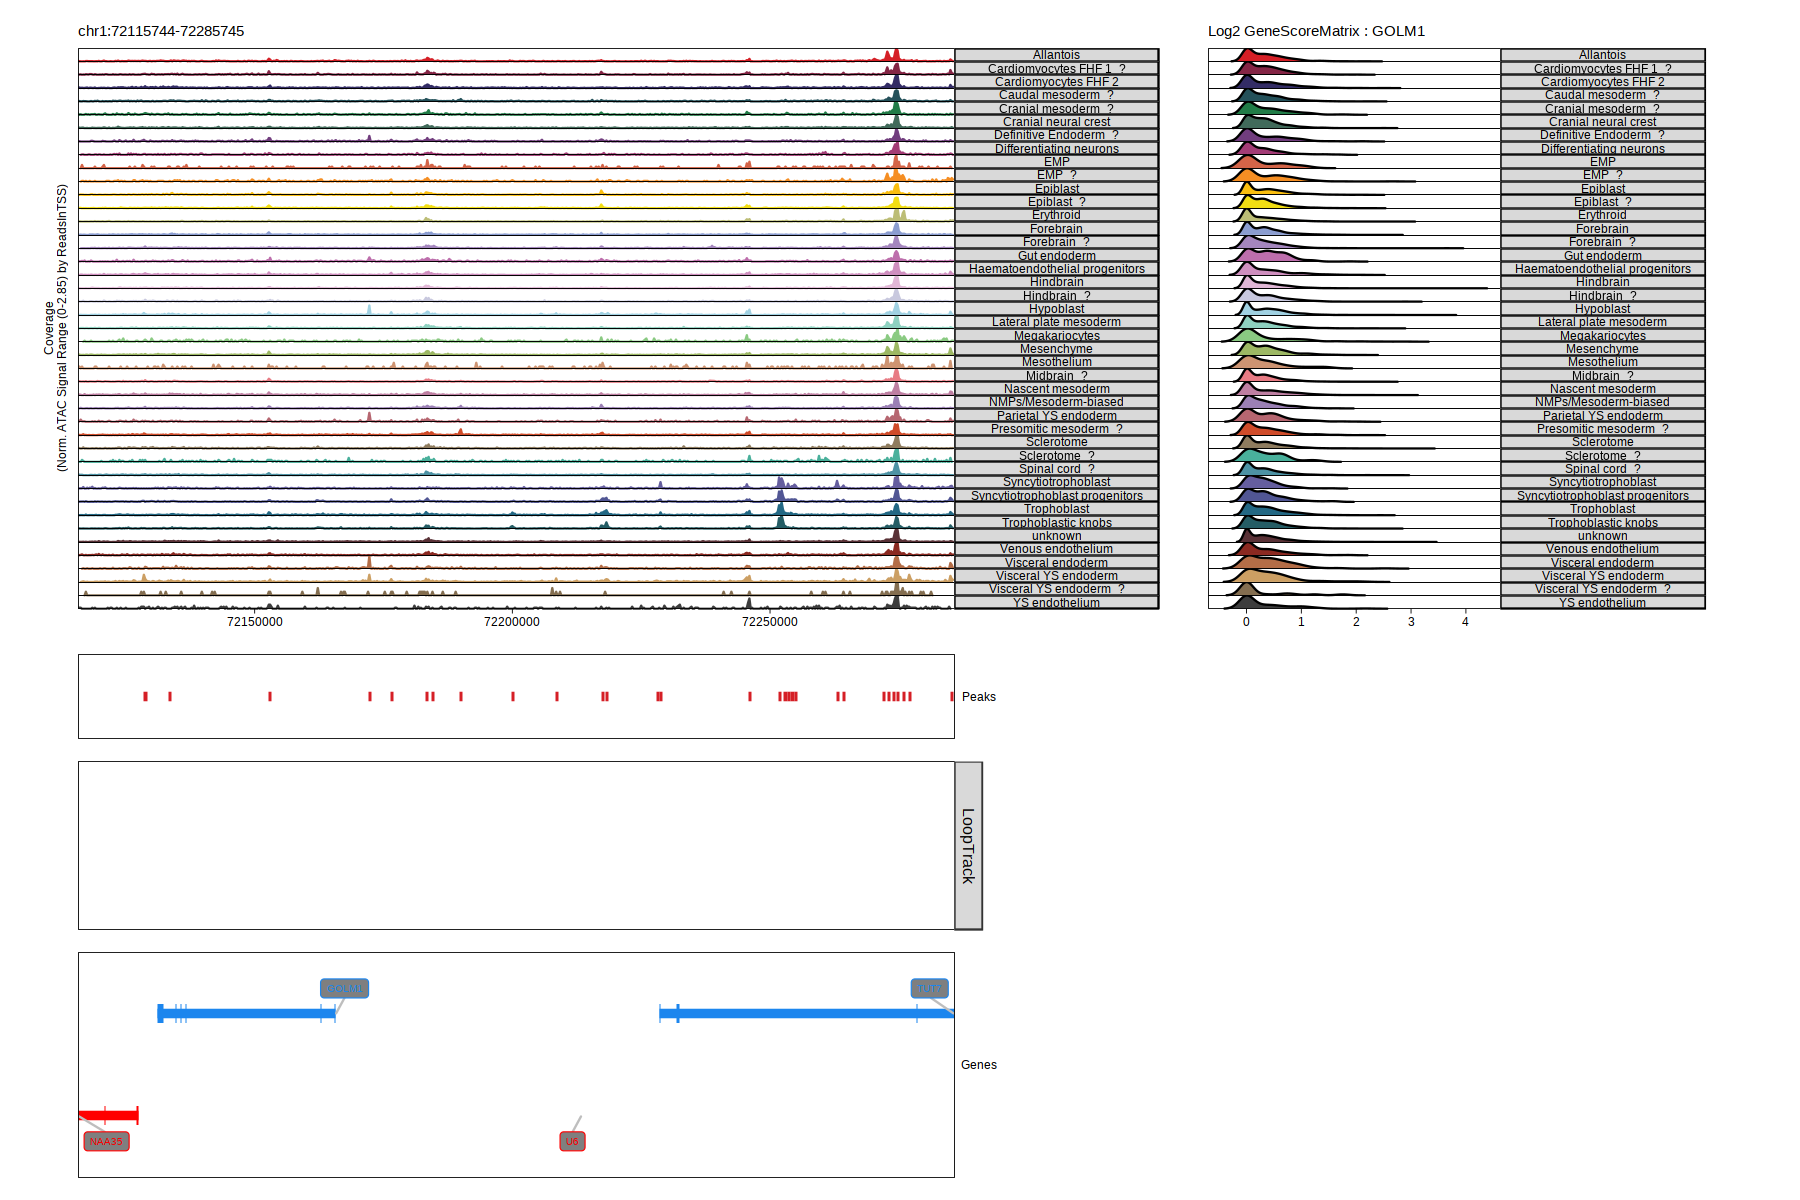

In [217]:
plotBrowserTrack(
  ArchRProj = ArchRProject,
  groupBy = "celltype_v1",
    geneSymbol = 'GOLM1', 
    useMatrix = 'GeneScoreMatrix',
    upstream = 50000,
  downstream = 120000,
     loops = getPeak2GeneLinks(ArchRProject))

In [76]:
peaks[peaks$idx %in% TF_genes[gene==genes]$idxATAC,0]

GRanges object with 8 ranges and 0 metadata columns:
     seqnames          ranges strand
        <Rle>       <IRanges>  <Rle>
  C5     chr1 8152900-8153500      *
  C5     chr1 8155842-8156442      *
  C5     chr1 8156946-8157546      *
  C9     chr1 8170771-8171371      *
  C5     chr1 8174903-8175503      *
  C5     chr1 8176920-8177520      *
  C5     chr1 8266570-8267170      *
  C9     chr1 8267788-8268388      *
  -------
  seqinfo: 22 sequences from an unspecified genome; no seqlengths